In [25]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [26]:
from seaborn import cm

In [27]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [28]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [64]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "toy_dataset"
dt_name = "german_credit"
dt_name = "adult48k"
dt_name = 'breast_cancer'
cf_method = ["dice","ils",'lore','growingspheres'][-1]



name_dataset = {"german_credit": "German Credit",
                "toy_dataset":"Toy Dataset",
                "adult48k":"Adult",
                "breast_cancer": "Breast Cancer",
                }[dt_name]
cf_results

'counterfactuals/'

In [65]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)

Loaded feature names from data/processed/breast_cancer/feature_names.csv
Loaded X_train from data/processed/breast_cancer/X_train.npz
Loaded y_train from data/processed/breast_cancer/y_train.npz
Loaded X_test from data/processed/breast_cancer/X_test.npz
Loaded y_test from data/processed/breast_cancer/y_test.npz
Loaded X_calibration from data/processed/breast_cancer/X_calibration.npz
Loaded y_calibration from data/processed/breast_cancer/y_calibration.npz


In [66]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for breast_cancer
Loaded random_forest model from models/breast_cancer/random_forest.pkl
Loaded existing random_forest model
Processing mlp for breast_cancer
Loaded mlp model from models/breast_cancer/mlp.pkl
Loaded existing mlp model
Processing xgboost for breast_cancer
Loaded xgboost model from models/breast_cancer/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for breast_cancer
Loaded lgbm model from models/breast_cancer/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [67]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    utl.plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.99
Model random_forest Accuracy: 0.96
Model random_forest F1 Score: 0.96
Model random_forest Balanced Accuracy: 0.95
■ 
 █

Model mlp ROC AUC: 0.99
Model mlp Accuracy: 0.98
Model mlp F1 Score: 0.98
Model mlp Balanced Accuracy: 0.97
■ 
 █

Model xgboost ROC AUC: 0.99
Model xgboost Accuracy: 0.98
Model xgboost F1 Score: 0.98
Model xgboost Balanced Accuracy: 0.97
■ 
 █

Model lgbm ROC AUC: 0.99
Model lgbm Accuracy: 0.97
Model lgbm F1 Score: 0.97
Model lgbm Balanced Accuracy: 0.96
■ 
 █



In [68]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [69]:
np.random.randint(0,7), np.random.rand()*7

(2, 1.3345519677109885)

In [70]:

                 
import pickle

#with open("debug/ranking_new_t.pkl", "rb") as f:
#    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


### The distances took into account

In [71]:
from src.distances import get_distances
metrics = ["l0", "l1", "l2", "inf", "sqeuclidean", "mae", "cosine", "chebyshev", "minkowski", "canberra", "braycurtis", "hamming", "jaccard", "wasserstein"]

In [72]:
'''
X = splits['X_test'].values[:10]

x = splits['X_test'].values[0]

print("Distance examples:")
for metric in metrics:
        distances = get_distances(X,x, policy=metric)
        #print(f"{metric} : {[f'{d:.2f}' for d in distances]}")
        plt.plot(distances, label=metric)
plt.legend()
plt.show()
'''

'\nX = splits[\'X_test\'].values[:10]\n\nx = splits[\'X_test\'].values[0]\n\nprint("Distance examples:")\nfor metric in metrics:\n        distances = get_distances(X,x, policy=metric)\n        #print(f"{metric} : {[f\'{d:.2f}\' for d in distances]}")\n        plt.plot(distances, label=metric)\nplt.legend()\nplt.show()\n'

In [73]:
all_stats = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}




In [74]:
all_stats_test = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}


## Scaled features?

In [75]:
scaled = False


In [76]:
'''fname = os.path.join(cf_method,dt_name+f"_ranking{'_scaled' if scaled else ''}.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+f"_ranking_test{'_scaled' if scaled else ''}.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")
'''

'fname = os.path.join(cf_method,dt_name+f"_ranking{\'_scaled\' if scaled else \'\'}.pkl")\nif utl.check_file_exists(fname):\n    with open(fname, "rb") as f:\n        all_stats = pickle.load(f)\n        print("Loaded",fname)\nelse:\n    print("!"*6,fname, "not found")\nfname_test = os.path.join(cf_method,dt_name+f"_ranking_test{\'_scaled\' if scaled else \'\'}.pkl")\nif utl.check_file_exists(fname_test):\n    with open(fname_test,\'rb\') as f:\n        all_stats_test = pickle.load(f)\n        print("Loaded",fname_test)\nelse:\n    print("!"*6,fname_test, "not found")\n'

In [77]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(0 elements computed)
random_forest computed? False
(0 elements computed)
	 test? False
(0 elements computed)
mlp computed? False
(0 elements computed)
	 test? False
(0 elements computed)
xgboost computed? False
(0 elements computed)
	 test? False
(0 elements computed)
lgbm computed? False
(0 elements computed)
	 test? False


In [78]:
compute_test = False

In [79]:
all_stats_tmp = all_stats_test if compute_test else all_stats
def select_test (x):return "test" in x if compute_test else ("test" not in x)

In [80]:
select_test("test"), select_test("train")

(False, True)

In [81]:
# do a fast check to see if the 
for k in models.keys():
    result_f = os.path.join("counterfactuals",k,dt_name)
    print(result_f)
    try:
        list_files = os.listdir(result_f)
        print("Number of files",len(list_files))
    except:
        print(result_f,"File not found")

counterfactuals/random_forest/breast_cancer
Number of files 8
counterfactuals/mlp/breast_cancer
Number of files 8
counterfactuals/xgboost/breast_cancer
Number of files 8
counterfactuals/lgbm/breast_cancer
Number of files 8


## Compute the distances 
Counterfactual should be already present

In [82]:
"growing_spheres",cf_method

('growing_spheres', 'growingspheres')

In [83]:
lipschitz_detailed = {}

for k in tqdm(models.keys()):
    result_folder_path = os.path.join(cf_results, k, dt_name)
    results = os.listdir(result_folder_path)
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    results = [r for r in results if select_test(r)]
    results = sorted(results, key=lambda x: os.path.getmtime(os.path.join(result_folder_path, x)), reverse=True)
    
    r = results[0]  # most recent
    cfs = np.load(os.path.join(result_folder_path, r), allow_pickle=True)
    
    lipschitz_detailed[k] = {
        'L_values': {metric: [] for metric in metrics},
        'original_conf': [],
        'cf_conf': [],
        'distances': {metric: [] for metric in metrics},
        'sample_idx': [],
        'correct': []
    }
    
    for i in range(cfs["cfs"].shape[0]):
        # Get original instance
        original_instance = splits[('X_test' if compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1,-1)
        original_class = cfs["cfs"][i]["true_class"].values
        
        # Original prediction
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        original_conf = pred_prob.max()
        correct = (original_class == pred).item()
        
        # Get counterfactuals
        if cf_method != "ils":
            good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        else:
            good_cfs = cfs["cfs"][i]["counterfactuals"].values
        
        if len(good_cfs) == 0:
            continue
        
        # Predict on each counterfactual individually
        cf_probs = models[k].predict_proba(good_cfs)
        
        good_cfs_norm = good_cfs
        original_instance_norm = original_instance
        
        # For each counterfactual
        for cf_idx in range(len(good_cfs)):
            cf_conf = cf_probs[cf_idx].max()
            delta_conf = np.abs(original_conf - cf_conf)
            
            for metric in metrics:
                if metric == '-inf':
                    continue
                # Distance to this specific counterfactual
                distance = get_distances(good_cfs_norm[cf_idx:cf_idx+1], 
                                        original_instance_norm, 
                                        policy=metric)[0]
                
                if distance > 0:
                    L = delta_conf / distance
                    
                    lipschitz_detailed[k]['L_values'][metric].append(L)
                    lipschitz_detailed[k]['distances'][metric].append(distance)
                else:
                    continue
                    #print(f"Skipping distance=0 for metric {metric}, model {k}, sample {i}, cf_idx {cf_idx}")
            lipschitz_detailed[k]['original_conf'].append(original_conf)
            lipschitz_detailed[k]['cf_conf'].append(cf_conf)
            lipschitz_detailed[k]['sample_idx'].append(i)
            lipschitz_detailed[k]['correct'].append(correct)

# Now you have MUCH richer data to analyze!

  0%|          | 0/4 [00:00<?, ?it/s]

In [1]:
'''
# 1. KDE plots per model and metric
fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4*len(metrics)))
if len(metrics) == 1:
    axes = [axes]

for idx, metric in enumerate(metrics):
    if metric in ['-inf', 'spearman','kendall']:
        continue
    for k in lipschitz_detailed.keys():
        L_vals = lipschitz_detailed[k]['L_values'][metric]
        if len(L_vals) > 0:
            # Optional: clip extreme outliers for better visualization
            L_vals_clipped = np.clip(L_vals, 0, np.percentile(L_vals, 95))
            sns.kdeplot(L_vals_clipped, label=k, ax=axes[idx])
    
    axes[idx].set_xlabel('Local Lipschitz Constant')
    axes[idx].set_title(f'{metric} norm')
    axes[idx].legend()

plt.tight_layout()
plt.show()
'''

"\n# 1. KDE plots per model and metric\nfig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4*len(metrics)))\nif len(metrics) == 1:\n    axes = [axes]\n\nfor idx, metric in enumerate(metrics):\n    if metric in ['-inf', 'spearman','kendall']:\n        continue\n    for k in lipschitz_detailed.keys():\n        L_vals = lipschitz_detailed[k]['L_values'][metric]\n        if len(L_vals) > 0:\n            # Optional: clip extreme outliers for better visualization\n            L_vals_clipped = np.clip(L_vals, 0, np.percentile(L_vals, 95))\n            sns.kdeplot(L_vals_clipped, label=k, ax=axes[idx])\n    \n    axes[idx].set_xlabel('Local Lipschitz Constant')\n    axes[idx].set_title(f'{metric} norm')\n    axes[idx].legend()\n\nplt.tight_layout()\nplt.show()\n"

## The interpretation of the following grpahs:

Ogni punto rappresenta un controfattuale. 

L'asse x mostra quanto abbiamo dovuto modificare l'istanza originale per ribaltare la predizione del modello. L'asse y mostra quanto drasticamente è cambiata la confidenza del modello rispetto a quella distanza (valori alti = più sensibile). 

I punti blu sono esempi classificati correttamente, i punti rossi sono esempi classificati erroneamente. Insight chiave: il modello sbaglia in regioni "instabili" (punti rossi in alto a sinistra) dove piccole variazioni causano grandi cambiamenti di confidenza, mentre le predizioni corrette provengono da regioni più stabili.

### TLDR:

Gli errori del modello (rosso) avvengono in regioni ad alta sensibilità dove la confidenza cambia drasticamente con piccole modifiche dell'input.

In [86]:
incorrect_c='orangered' 
correct_c='forestgreen' 

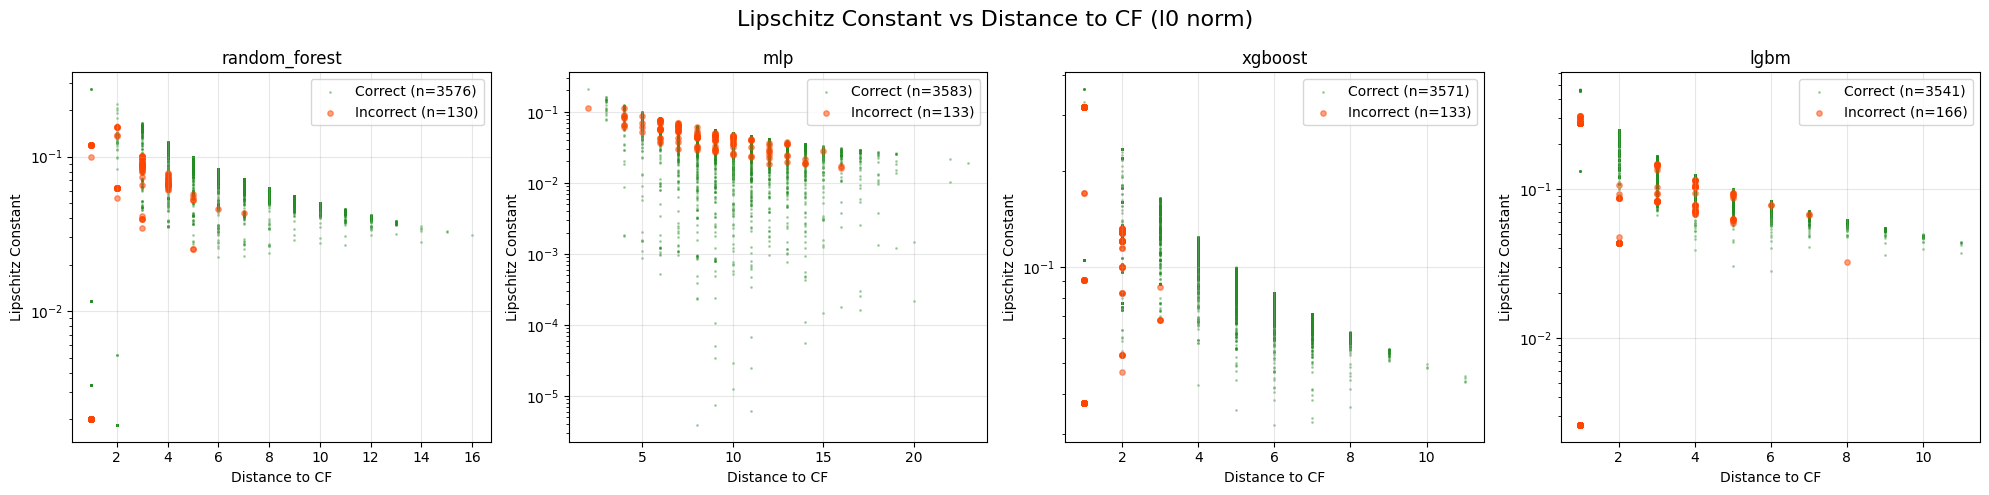

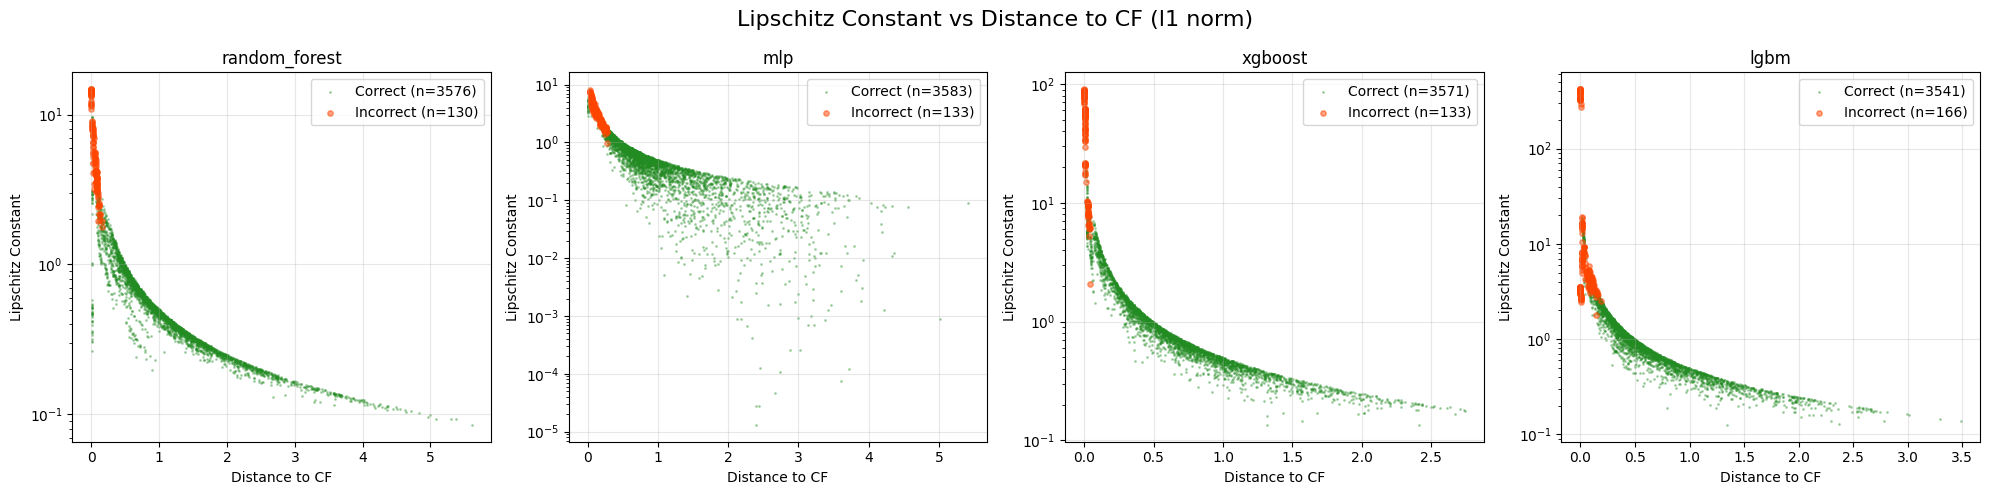

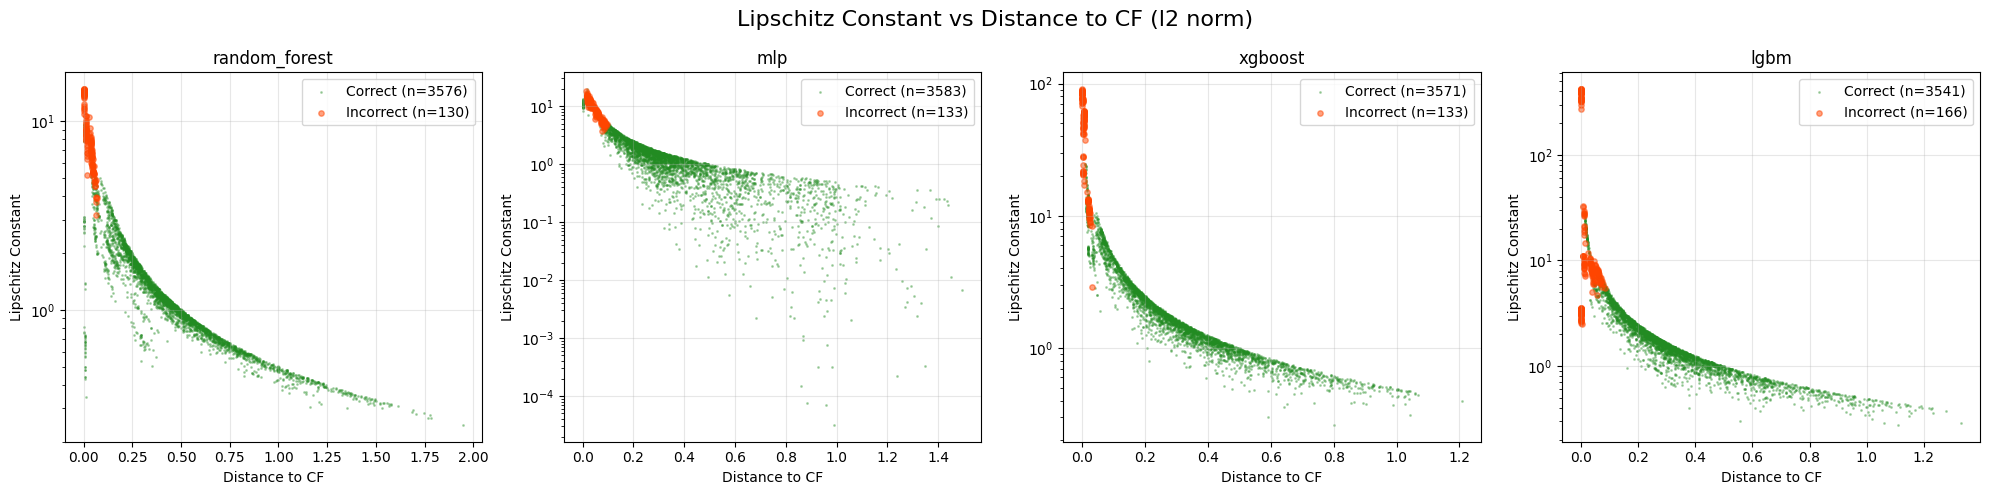

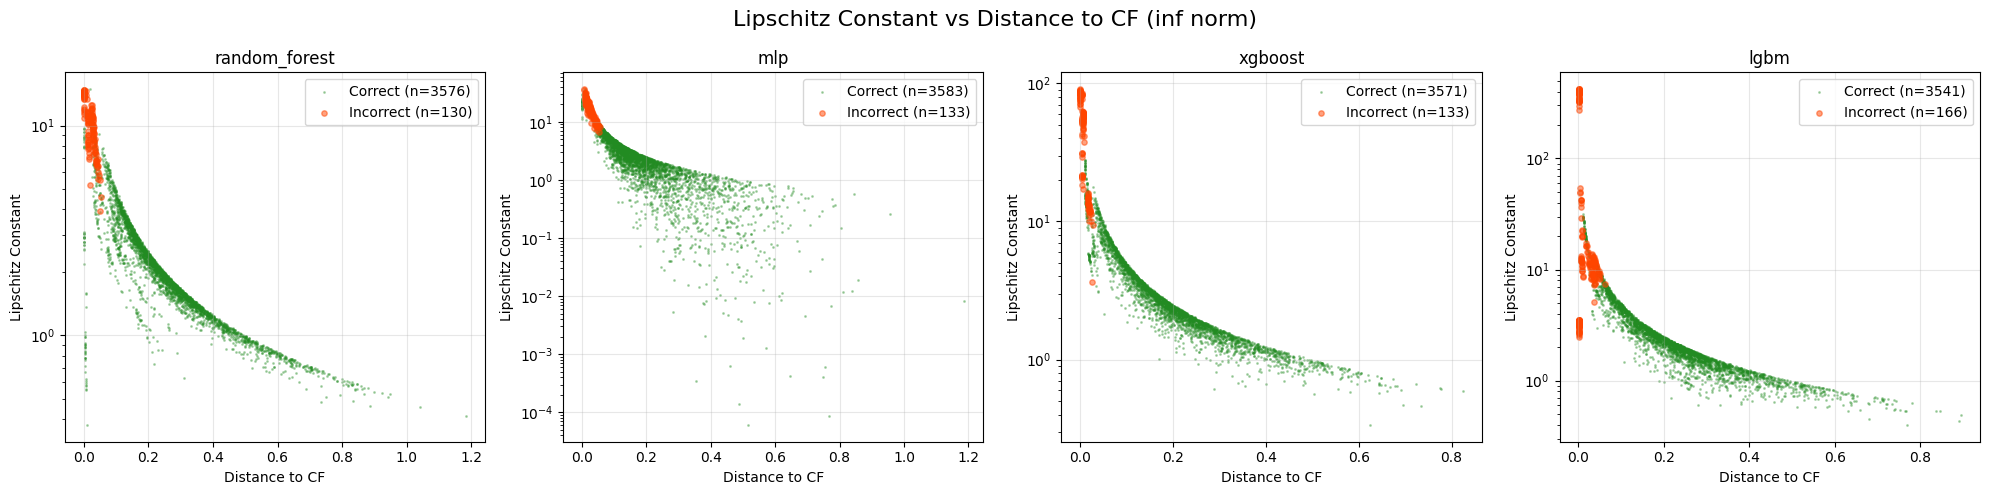

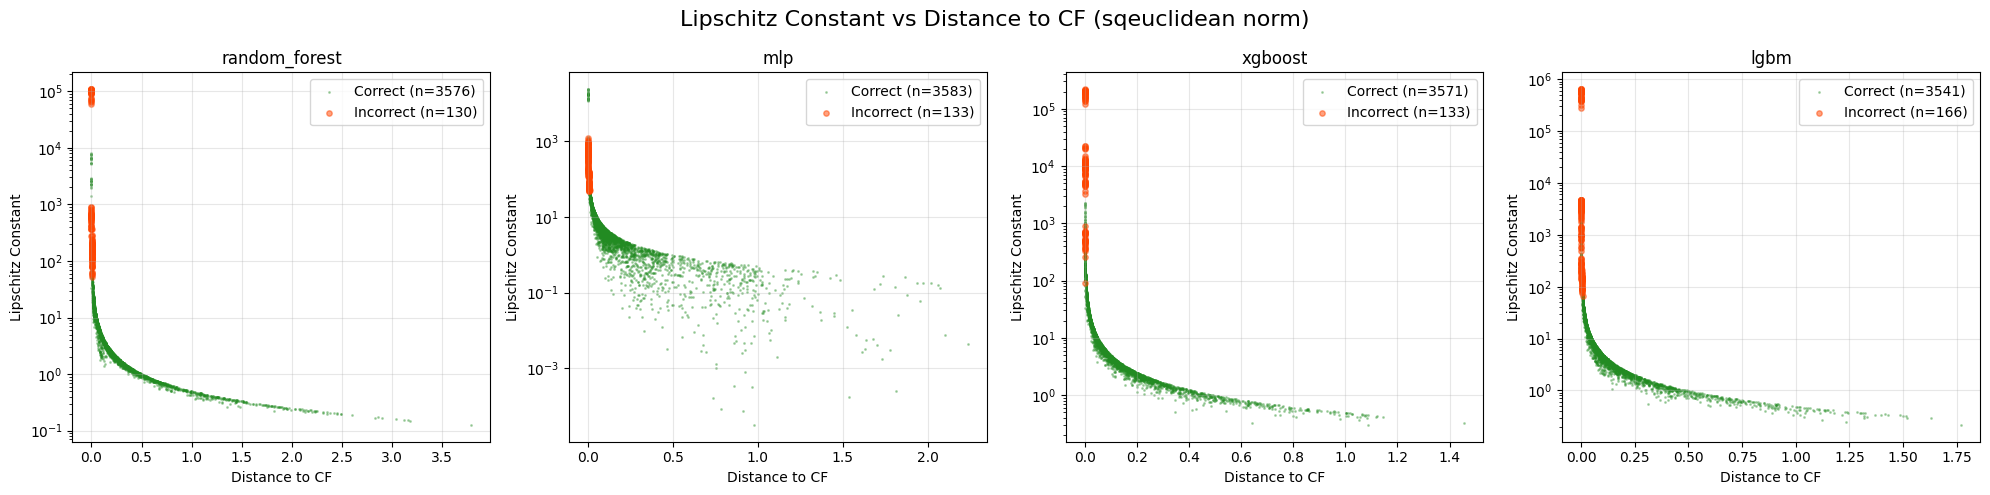

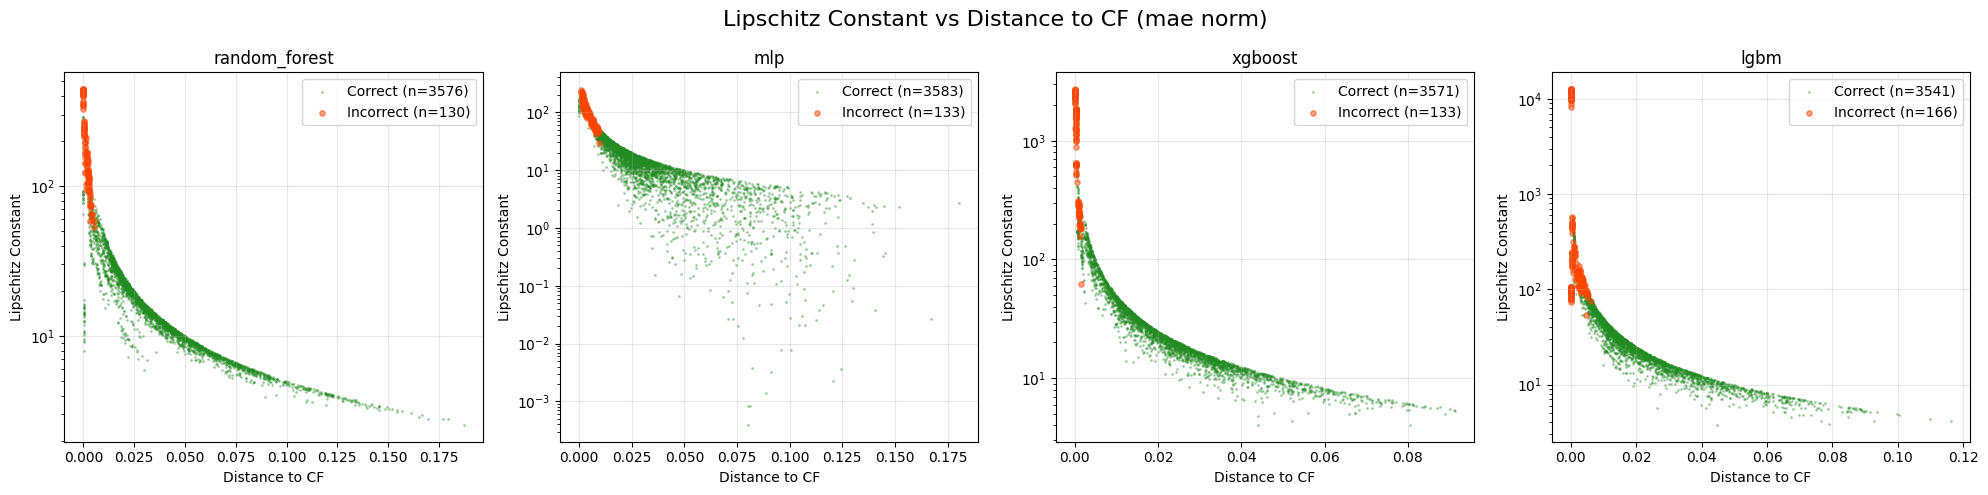

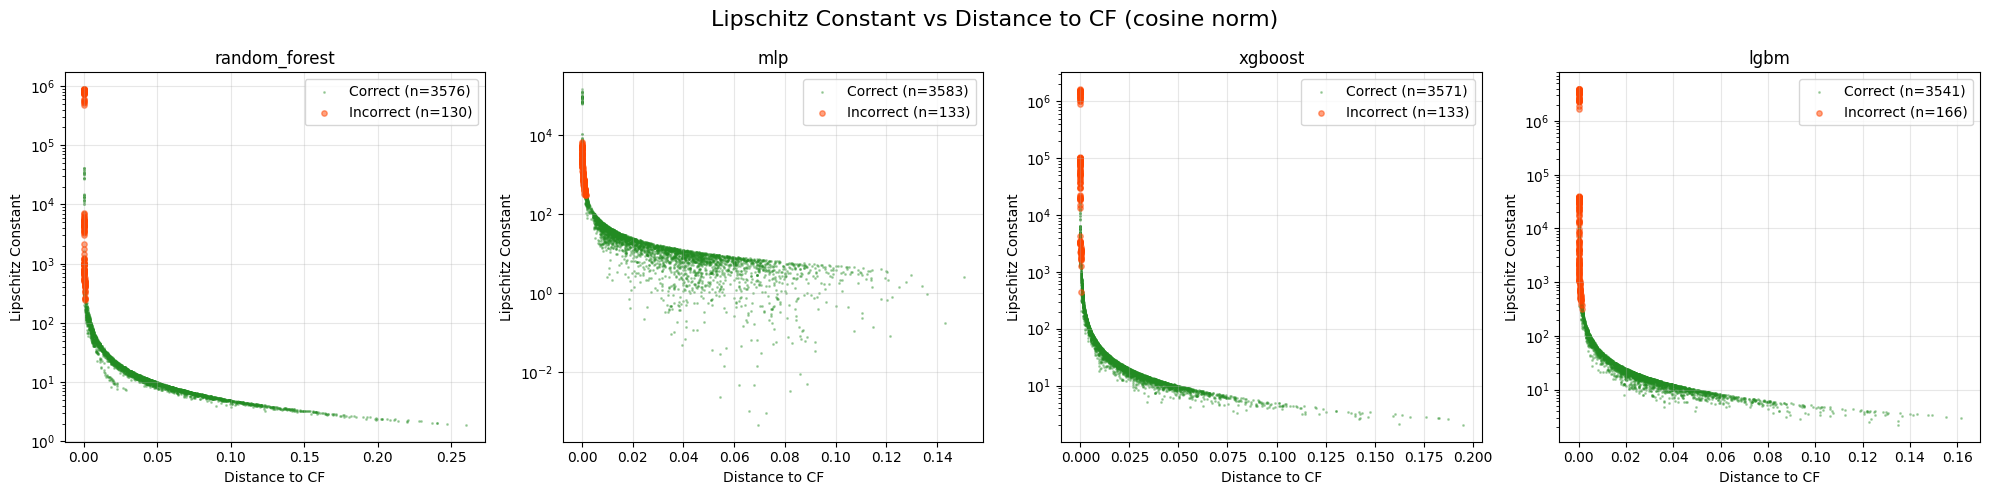

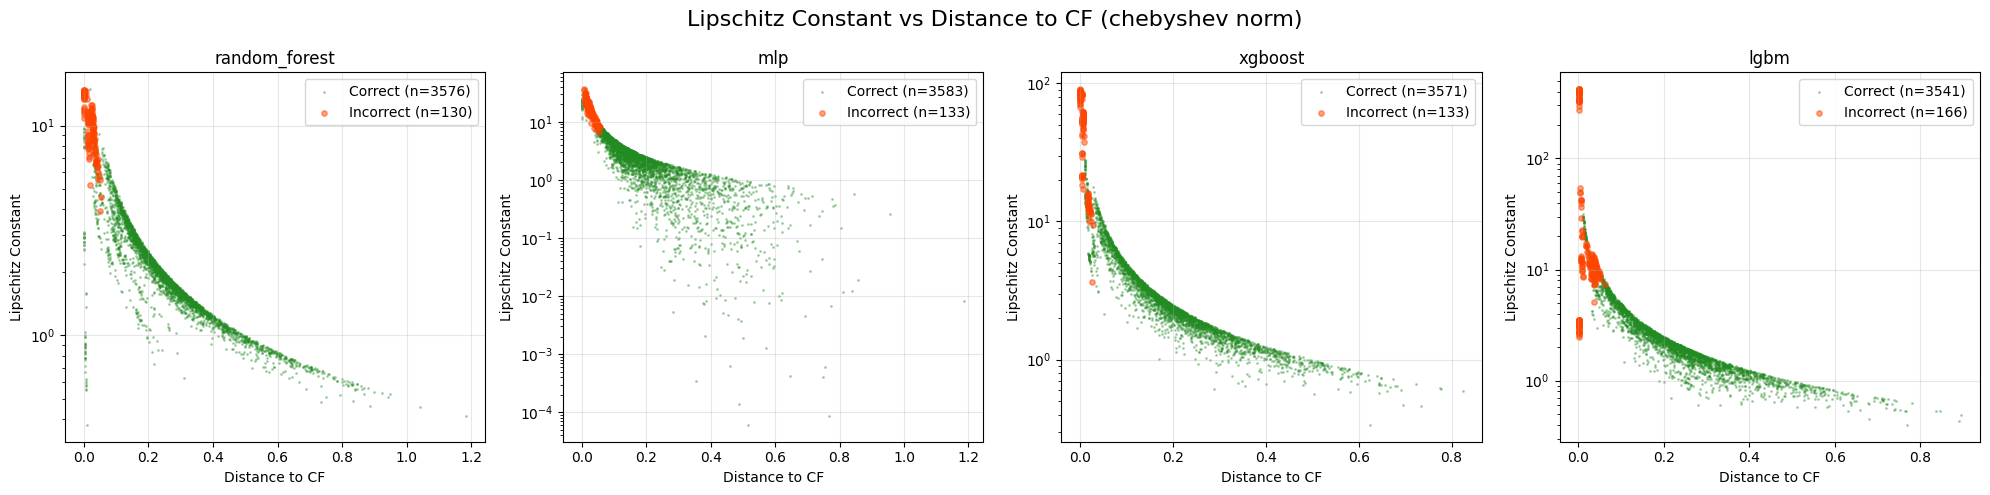

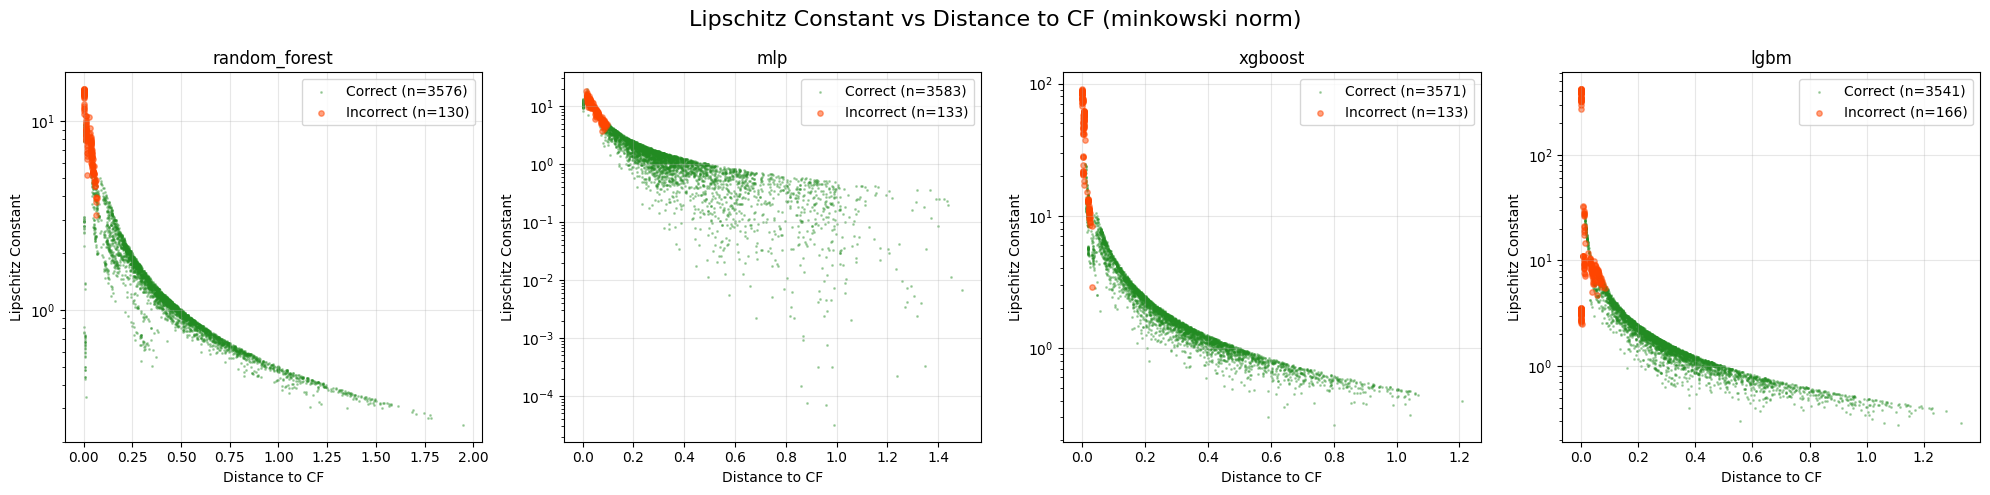

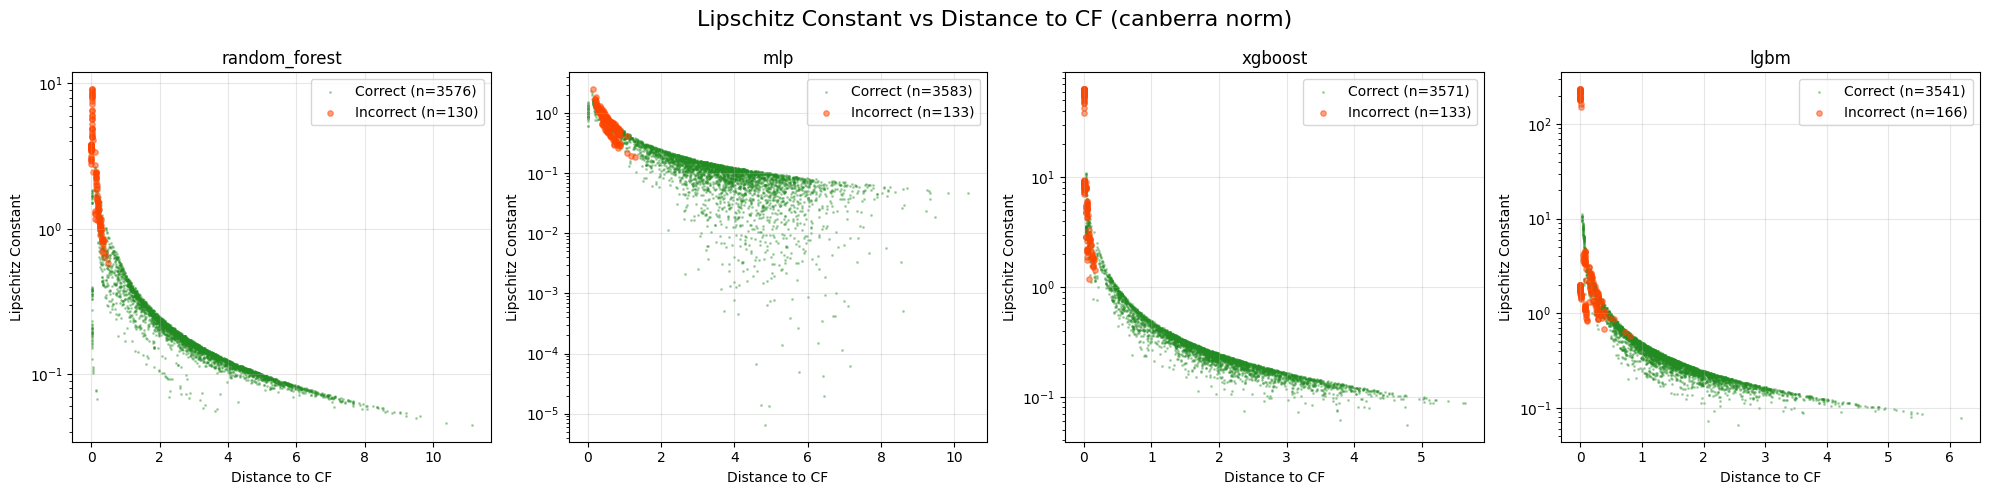

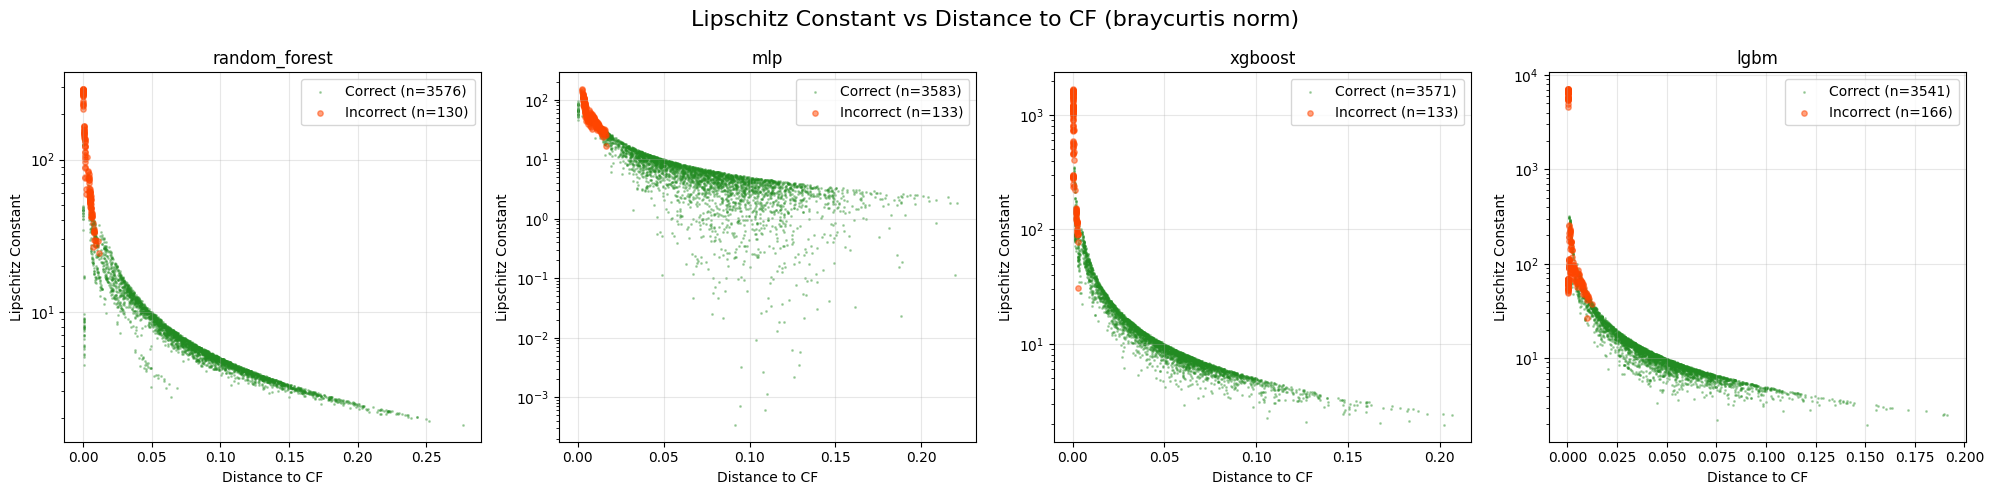

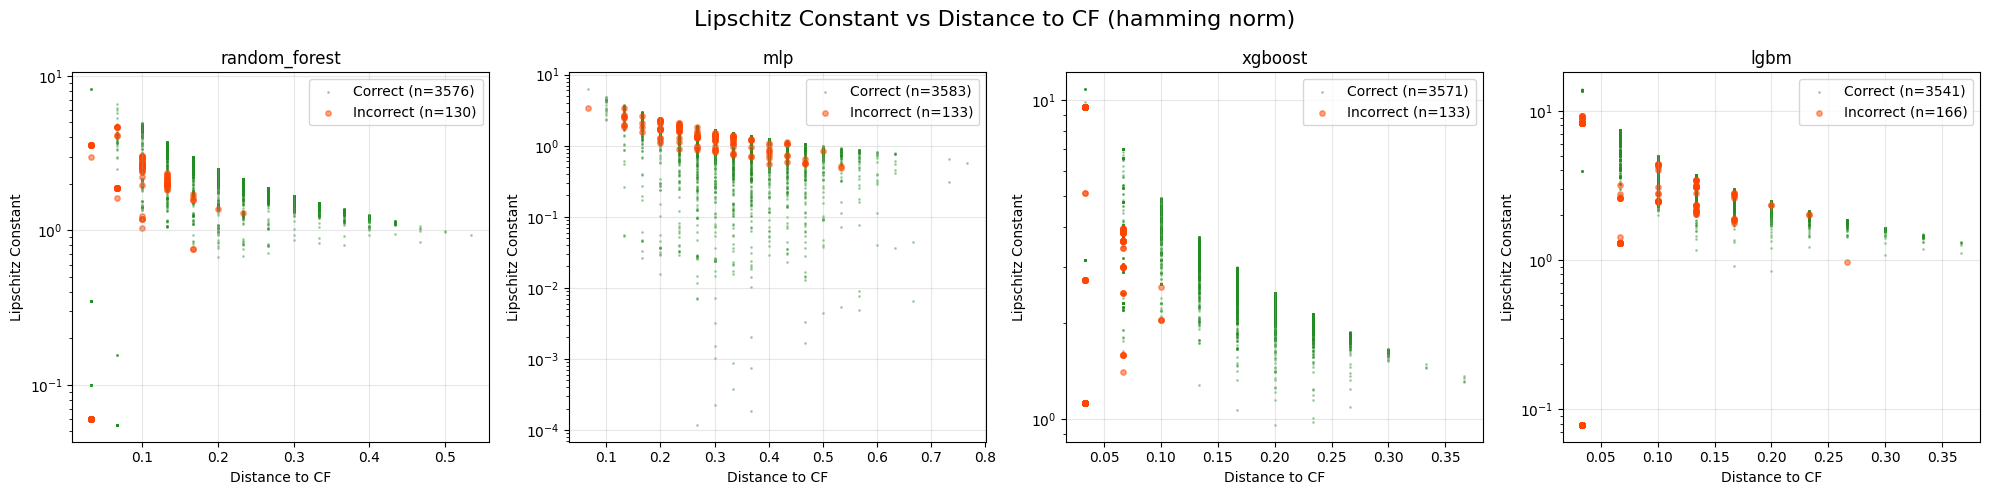

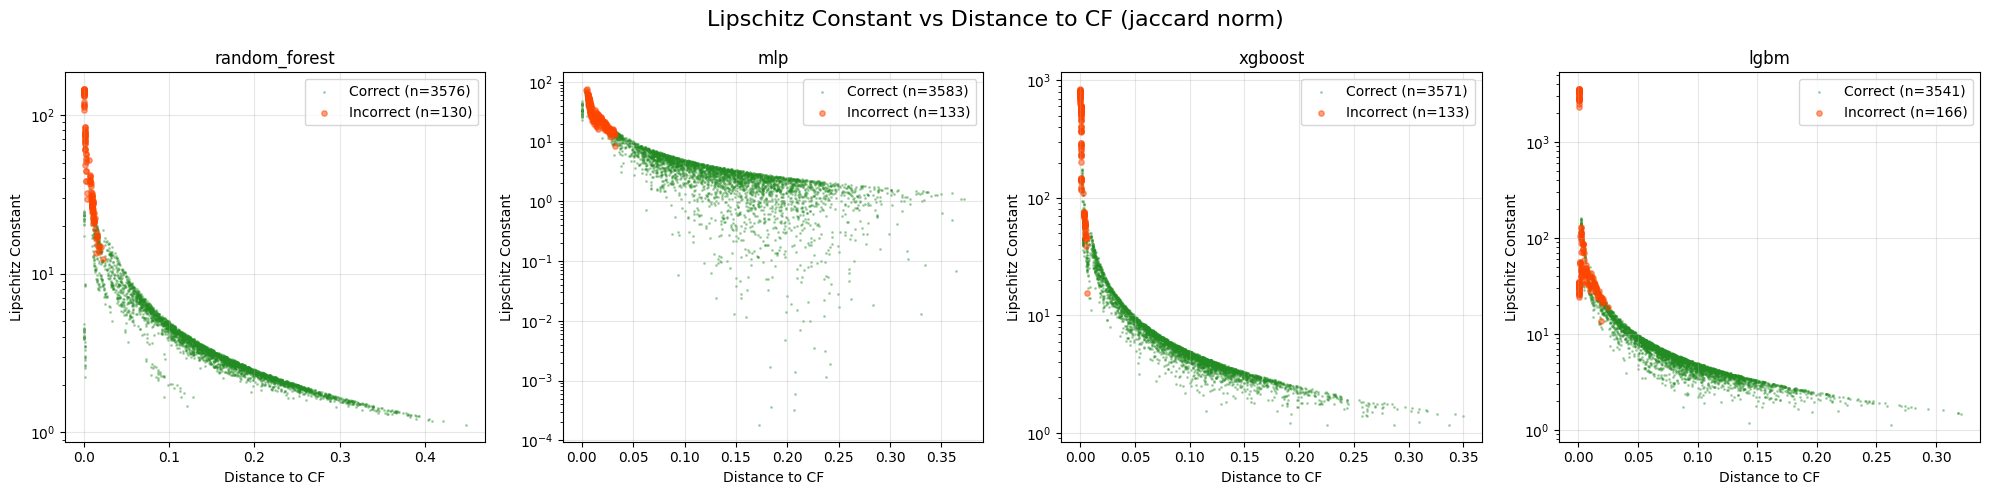

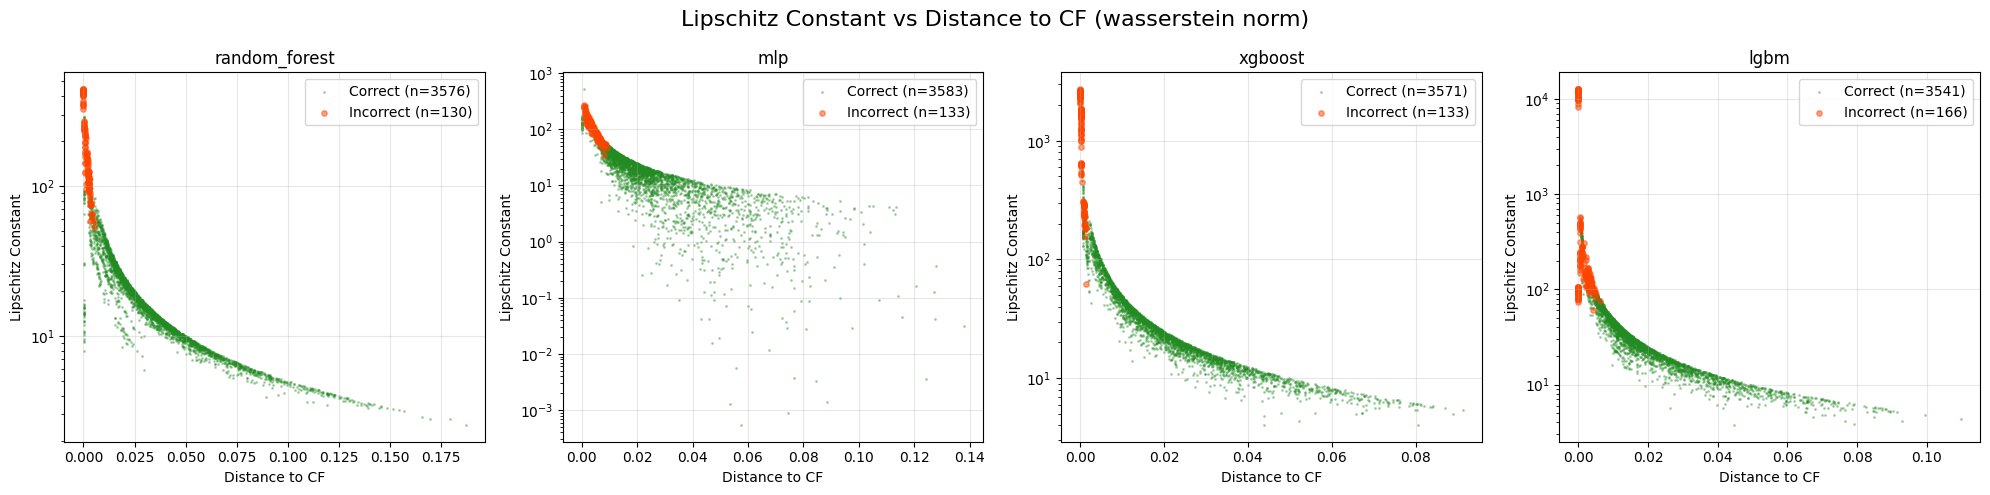

In [87]:
# 2. Lipschitz vs Distance scatter plot with correct/incorrect coloring
for metric in metrics:
    if metric in ['-inf', 'spearman','kendall']:
        continue
    fig, axes = plt.subplots(1, len(models.keys()), figsize=(5*len(models.keys()), 5))
    if len(models.keys()) == 1:
        axes = [axes]

    ybounds = []
    plt.suptitle(f'Lipschitz Constant vs Distance to CF ({metric} norm)', fontsize=16)
    for idx, k in enumerate(lipschitz_detailed.keys()):
        #metric = 'l1'  # choose your metric
        
        # Separate correct and incorrect predictions
        distances = np.array(lipschitz_detailed[k]['distances'][metric])
        L_values = np.array(lipschitz_detailed[k]['L_values'][metric])
        correct = np.array(lipschitz_detailed[k]['correct'])
        
        
        # Plot correct predictions (blue/green)
        axes[idx].scatter(distances[correct],
                        L_values[correct],
                        marker='.',
                        alpha=0.3, s=5, c=correct_c,
                        label=f'Correct (n={correct.sum()})')
        # Plot incorrect predictions (red/orange)
        axes[idx].scatter(distances[~correct],
                        L_values[~correct],
                        alpha=0.5, s=15, c=incorrect_c, 
                        label=f'Incorrect (n={(~correct).sum()})')
        
        axes[idx].set_xlabel('Distance to CF')
        axes[idx].set_ylabel('Lipschitz Constant')
        axes[idx].set_title(k)
        axes[idx].set_yscale('log')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, alpha=0.3)
        ybounds.append(axes[idx].get_ylim())


    plt.tight_layout()
    plt.show()

In [29]:

# 3. Compare correct vs incorrect predictions
for k in lipschitz_detailed.keys():
    metric = 'l2'
    L_correct = [L for L, c in zip(lipschitz_detailed[k]['L_values'][metric], 
                                    lipschitz_detailed[k]['correct']) if c]
    L_incorrect = [L for L, c in zip(lipschitz_detailed[k]['L_values'][metric], 
                                      lipschitz_detailed[k]['correct']) if not c]
    
    print(f"\n{k}:")
    print(f"  Correct predictions - Mean L: {np.mean(L_correct):.4f}, Median: {np.median(L_correct):.4f}")
    print(f"  Incorrect predictions - Mean L: {np.mean(L_incorrect):.4f}, Median: {np.median(L_incorrect):.4f}")


random_forest:
  Correct predictions - Mean L: 0.3250, Median: 0.2150
  Incorrect predictions - Mean L: 0.5191, Median: 0.3064

mlp:
  Correct predictions - Mean L: 0.3233, Median: 0.2891
  Incorrect predictions - Mean L: 0.3279, Median: 0.2469

xgboost:
  Correct predictions - Mean L: 0.1230, Median: 0.0417
  Incorrect predictions - Mean L: 0.1647, Median: 0.0872

lgbm:
  Correct predictions - Mean L: 0.1119, Median: 0.0378
  Incorrect predictions - Mean L: 0.1545, Median: 0.0858


In [1]:
print("Ready?")

Ready?


## Save files for the distances
if not already present

In [ ]:
if compute_test:
    all_stats_test = all_stats_tmp
else:
    all_stats = all_stats_tmp
compute_test

## End of File